Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

[OPTIMIZER] epoch_start=0 global_step=0 wrapped=AcceleratedOptimizer base=AdamW lr=0.0 id=140669347715392 hyperparams={'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 2e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 2e-05}
[SCHEDULER]   scheduler_last_lr=[0.0]
[PARAMS]   params_total=109,484,547 params_trainable=109,484,547


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro,Mse,Sse
1,0.256200,0.140320,0.950000,0.949878,0.949977,0.950000,0.024010,7.203073
2,0.130400,0.123828,0.966667,0.966612,0.966849,0.966667,0.018672,5.601533
3,0.081100,0.132100,0.963333,0.963331,0.963456,0.963333,0.019700,5.910021
4,0.019300,0.168676,0.963333,0.963242,0.963564,0.963333,0.023310,6.992923


[TRAINING_PERFORMANCE] epoch=1.0 tokens=0 time=24.46s tok/s=0.0 ex/s=0.00 peak_mem=2.07GiB lr=1.60e-05
[EVALUATION_PERFORMANCE] tokens=81920 time=0.16s tok/s=527499.9 ex/s=4121.09
[EVALUATION_PERFORMANCE] accuracy=0.9500 cost=$0.01 accuracy_per_$=67.09
[OPTIMIZER] epoch_start=1.0 global_step=150 wrapped=AcceleratedOptimizer base=AdamW lr=1.595744680851064e-05 id=140669347715392 hyperparams={'lr': 1.595744680851064e-05, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 2e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 1.595744680851064e-05, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 2e-05}
[SCHEDULER]   scheduler_last_lr=[1.595744680851064e-05]
[PARAMS]   p

[EVALUATION_PERFORMANCE] tokens=81920 time=0.16s tok/s=528095.2 ex/s=4125.74
[EVALUATION_PERFORMANCE] accuracy=0.9233 cost=$0.09 accuracy_per_$=10.85

### BERT-BASE-UNCASED EVALUATION METRICS ###
{'epoch': 4.0,
 'eval_accuracy': 0.9233333333333333,
 'eval_f1_macro': 0.9233953395339535,
 'eval_loss': 0.23848313093185425,
 'eval_mse': 0.03813982141635632,
 'eval_precision_macro': 0.9235814325730293,
 'eval_recall_macro': 0.9233333333333333,
 'eval_runtime': 0.2238,
 'eval_samples_per_second': 1340.409,
 'eval_sse': 11.441946424906897,
 'eval_steps_per_second': 22.34}


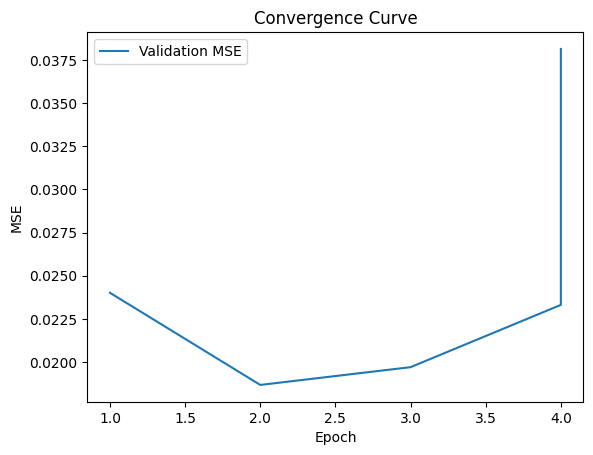

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2400 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

In [1]:
# A State Space Model Approach to Cross-Lingual Sentiment Analysis of Filipino Texts 


import os
import pandas as pd
import pprint

from pathlib import Path
from transformers import pipeline

from src.config import *
from src.metrics import evaluate_pipe
from src import (
    context,
    helper,
    sentiment, 
    utility, 
)

os.environ["HF_DATASETS_DISABLE_CACHING"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
helper.list_config()

if App.HAS_GPU:
    os.environ["MAMBA_USE_MAMBAPY"] = Mamba.FORCE_CUDA
    os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

if App.ACTION == "TRAIN":
    bert_context = context.setup_pipeline(Bert, require_translation = False)
    bert_trainer = sentiment.train(bert_context)

